# Ноутбук 8 — Эксперимент 5: SHAP-интерпретация лучшей модели

**Назначение.** Вычисление SHAP-значений XGBoost block-level (обучен на всех
32 участниках), построение summary-bar, beeswarm и dependence-plot для топ-3
признаков.

**Главное наблюдение.** Признак `left_pupil_deriv_mean_std` доминирует
(|SHAP| = 1,31 — в 4,5 раза больше следующего).

In [1]:
import sys
from pathlib import Path

NB_ROOT = Path.cwd()
if str(NB_ROOT) not in sys.path:
    sys.path.insert(0, str(NB_ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from modules import config
from modules.experiments import build_block_level_dataset, make_xgboost_block
import xgboost as xgb

print(f"Notebooks root: {NB_ROOT}")

Notebooks root: D:\Programming\Python\Diplom\notebooks


## 8.1 Обучение XGBoost на всех 32 точках (для интерпретации)

In [2]:
windows = pd.read_csv(config.RESULTS_DIR / "feature_table.csv")
block = build_block_level_dataset(windows)
feat_cols = [c for c in block.columns
             if c not in {"participant", "ssq_post_total", "ssq_pre_total",
                          "ssq_delta", "ssq_high"}]
X = block[feat_cols]
y = block["ssq_high"].to_numpy(dtype=int)

model = make_xgboost_block()
model.fit(X, y)
imp = model.named_steps["imputer"]
xgb_model = model.named_steps["model"]
X_imp = pd.DataFrame(imp.transform(X), columns=feat_cols)

print(f"Обучено на {X.shape[0]} участниках × {X.shape[1]} признаках")
print(f"Точность на train: {(model.predict(X) == y).mean():.4f}")

Обучено на 32 участниках × 286 признаках
Точность на train: 1.0000


## 8.2 SHAP через нативный механизм XGBoost

Для XGBoost SHAP-значения можно получить точно через
`Booster.predict(pred_contribs=True)`, без библиотеки `shap`.

In [3]:
booster = xgb_model.get_booster()
dmatrix = xgb.DMatrix(X_imp.values, feature_names=feat_cols)
shap_raw = booster.predict(dmatrix, pred_contribs=True)
shap_values = shap_raw[:, :-1]  # последний столбец = bias
print(f"SHAP shape: {shap_values.shape}")

SHAP shape: (32, 286)


## 8.3 Топ-20 признаков по среднему |SHAP|

In [4]:
mean_abs = np.abs(shap_values).mean(axis=0)
top_df = pd.DataFrame({"feature": feat_cols, "mean_abs_shap": mean_abs})
top_df = top_df.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
top_df.head(20).to_csv(config.RESULTS_DIR / "exp05_shap_top20.csv", index=False)
print(top_df.head(20).to_string(index=False))

                  feature  mean_abs_shap
left_pupil_deriv_mean_std       1.309400
      gaze_pitch_min_mean       0.288455
     gaze_yaw_median_mean       0.272130
              bvp_min_std       0.259761
            hrv_pnn50_std       0.179075
         gaze_yaw_max_std       0.125597
         gaze_yaw_rms_std       0.115294
            bvp_skew_mean       0.106541
       left_pupil_max_std       0.076037
            bvp_mean_mean       0.074774
       left_pupil_std_std       0.074234
           hrv_rmssd_mean       0.072339
   left_pupil_median_mean       0.064913
       gaze_yaw_mean_mean       0.063506
      right_pupil_std_std       0.063168
      left_pupil_skew_std       0.062385
        gaze_yaw_max_mean       0.056472
         head_yaw_max_std       0.043190
     left_pupil_mean_mean       0.043117
     left_pupil_kurt_mean       0.039156


## 8.4 Bar-plot топ-20

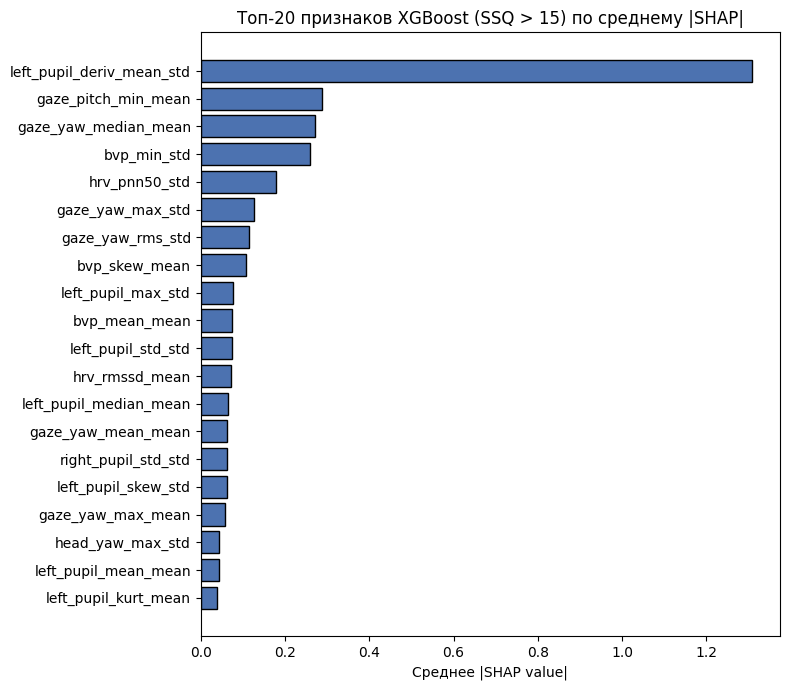

In [5]:
top20 = top_df.head(20)[::-1]
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top20["feature"], top20["mean_abs_shap"], color="#4C72B0", edgecolor="black")
ax.set_xlabel("Среднее |SHAP value|")
ax.set_title("Топ-20 признаков XGBoost (SSQ > 15) по среднему |SHAP|")
plt.tight_layout()
fig_dir = config.RESULTS_DIR / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_dir / "fig12_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

## 8.5 Beeswarm-plot для топ-15 — fig13

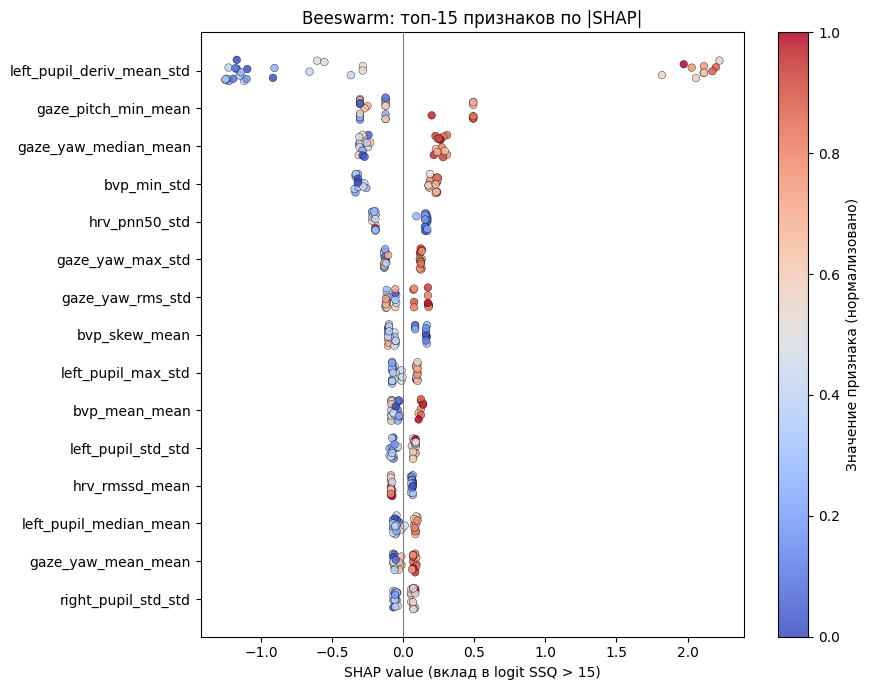

In [6]:
# Beeswarm: для каждого из топ-15 признаков точки = SHAP value одного участника,
# цвет = значение признака (низкое/высокое). Реализация без библиотеки shap.
top_n = 15
mean_abs_full = np.abs(shap_values).mean(axis=0)
order = np.argsort(mean_abs_full)[::-1][:top_n]
sub_names = [feat_cols[i] for i in order][::-1]  # снизу вверх по важности

fig, ax = plt.subplots(figsize=(9, 7))
rng = np.random.default_rng(42)
for row_pos, feat_idx in enumerate(order[::-1]):
    sv = shap_values[:, feat_idx]
    feat_vals = X_imp.iloc[:, feat_idx].values
    if feat_vals.std() > 1e-9:
        norm = (feat_vals - feat_vals.min()) / (feat_vals.max() - feat_vals.min() + 1e-12)
    else:
        norm = np.zeros_like(feat_vals)
    jitter = rng.uniform(-0.3, 0.3, size=len(sv))
    sc = ax.scatter(sv, np.full_like(sv, row_pos, dtype=float) + jitter,
                    c=norm, cmap="coolwarm", s=30, alpha=0.85,
                    edgecolor="black", linewidth=0.3)

ax.axvline(0, color="gray", linewidth=0.8)
ax.set_yticks(range(top_n))
ax.set_yticklabels(sub_names)
ax.set_xlabel("SHAP value (вклад в logit SSQ > 15)")
ax.set_title(f"Beeswarm: топ-{top_n} признаков по |SHAP|")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Значение признака (нормализовано)")
fig.tight_layout()
fig_dir = config.RESULTS_DIR / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_dir / "fig13_shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

## 8.6 Dependence-plot для топ-3 — fig14

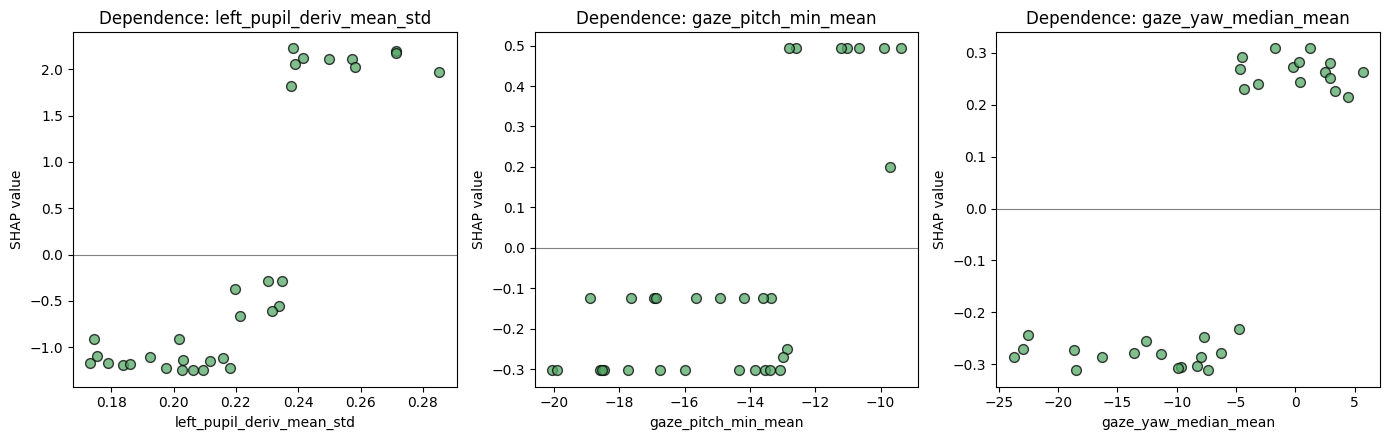

In [7]:
top3 = top_df.head(3)["feature"].tolist()
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, feat in zip(axes, top3):
    idx = feat_cols.index(feat)
    ax.scatter(X_imp.iloc[:, idx], shap_values[:, idx],
               s=50, alpha=0.75, edgecolor="black", color="#55A868")
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.set_xlabel(feat)
    ax.set_ylabel("SHAP value")
    ax.set_title(f"Dependence: {feat}")
plt.tight_layout()
fig.savefig(fig_dir / "fig14_shap_dependence.png", dpi=150, bbox_inches="tight")
plt.show()

## 8.7 Распределение значимости по каналам

In [8]:
def channel_of(c):
    if c.startswith(("left_pupil", "right_pupil")): return "pupil"
    if c.startswith("gaze"):     return "gaze"
    if c.startswith("head"):     return "head"
    if c.startswith("bvp"):      return "bvp"
    if c.startswith("hrv"):      return "hrv"
    if c.startswith("eda"):      return "eda"
    if c.startswith("hr_"):      return "hr"
    if c.startswith("skt"):      return "skt"
    if c.startswith("acc"):      return "acc"
    return "other"

top20 = top20.copy()
top20["channel"] = top20["feature"].apply(channel_of)
by_ch = top20.groupby("channel")["mean_abs_shap"].sum().sort_values(ascending=False)
print("Сумма |SHAP| по каналам в топ-20:")
print(by_ch.round(4).to_string())

Сумма |SHAP| по каналам в топ-20:
channel
pupil    1.7324
gaze     0.9215
bvp      0.4411
hrv      0.2514
head     0.0432


## 8.8 Выводы

* **Доминирует `left_pupil_deriv_mean_std`** (|SHAP| = 1,31, ×4,5 от следующего).
  Это стандартное отклонение средней per-окно производной диаметра левого зрачка
  — нестабильность зрачковой реакции в течение сессии.
* В топ-20: pupil ~63%, gaze ~25%, BVP/HRV ~16%, head ~1%. ЭДА, температуры
  кожи, акселерометрии, ЧСС в топ-20 нет.
* Согласуется с VR-LENS: eye-tracking — главная категория признаков для
  cybersickness; уточняет относительно PRECYSE, где упор на ЭДА/HRV
  (там активный VR-контент с большей симпатической активацией).